In [2]:
%pip install openpyxl 

     -------------------------------------- 250.9/250.9 kB 1.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.shape

(541909, 8)

# Data Exploration

The dataset contains transaction-level retail data with customer, invoice, and pricing details.

Missing values are present in CustomerID and Description.
Since RFM analysis is customer-centric, records without CustomerID will be removed.
The data is at a line-item level, so multiple rows may belong to the same transaction.

In [9]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantities (returns/cancellations)
df = df[df['Quantity'] > 0]

# Remove duplicates
df = df.drop_duplicates()

In [10]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [11]:
df.shape

(392732, 8)

# Data Cleaning

Records with missing CustomerID were removed, along with transactions having non-positive quantities, as they represent returns or cancellations. Duplicate records were also removed to ensure data accuracy.

In [15]:
df = df.drop(columns=["TotalAmount"])

In [13]:
# Reference date (one day after last transaction)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM calculation
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalAmount': 'sum'  # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Reset index
rfm = rfm.reset_index()

In [17]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


# RFM Calculation

RFM metrics were computed at the customer level by aggregating transaction data. Recency measures the number of days since the last purchase, frequency represents the number of unique transactions, and monetary captures the total spend per customer.

In [21]:
rfm['F_score'] = pd.qcut(rfm['Frequency'], q=4, labels=False, duplicates='drop') + 1
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=4, labels=False, duplicates='drop') + 1
rfm['R_score'] = pd.qcut(rfm['Recency'], q=4, labels=False, duplicates='drop')
rfm['R_score'] = 4 - rfm['R_score']  # reverse

RFM Scoring

RFM values were converted into scores using quartile-based binning. Recency was inversely scored, with more recent customers receiving higher scores, while frequency and monetary values were scored directly based on their distribution. Due to skewness and repeated values in the data, duplicate bin edges were handled by adjusting the quantile bins dynamically, ensuring robust and data-driven scoring.

In [22]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346,326,1,77183.60,1,1,4
1,12347,2,7,4310.00,4,3,4
2,12348,75,4,1797.24,2,2,4
3,12349,19,1,1757.55,3,1,4
4,12350,310,1,334.40,1,1,2


In [23]:
def segment_customer(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'Champions'
    elif row['F_score'] >= 3 and row['M_score'] >= 2:
        return 'Loyal'
    elif row['R_score'] <= 2 and row['F_score'] >= 2:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [24]:
rfm['Segment'].value_counts()

Segment
Lost         3021
Champions     754
At Risk       448
Loyal         116
Name: count, dtype: int64

# Customer Segmentation

Customer segments were defined using all three RFM dimensions. High recency, frequency, and monetary customers were classified as Champions, while customers with strong purchase behavior but slightly lower value were categorized as Loyal. Customers with declining engagement were labeled At Risk, and those with low recency and frequency were classified as Lost.

Matplotlib is building the font cache; this may take a moment.


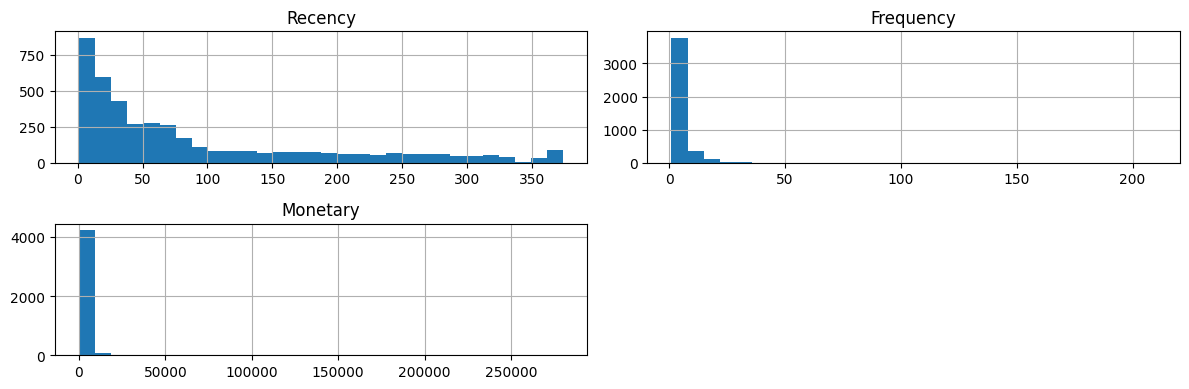

In [25]:
import matplotlib.pyplot as plt

rfm[['Recency','Frequency','Monetary']].hist(bins=30, figsize=(12,4))
plt.tight_layout()
plt.show()

Insight: 
- The Recency distribution shows a strong concentration of customers with low recency values, indicating many recent buyers, but also a long tail of inactive customers.
- The Frequency distribution is highly skewed, with most customers making very few purchases, while a small group shows high purchase frequency.
- The Monetary distribution is heavily right-skewed, indicating that a small number of customers contribute disproportionately to total revenue.

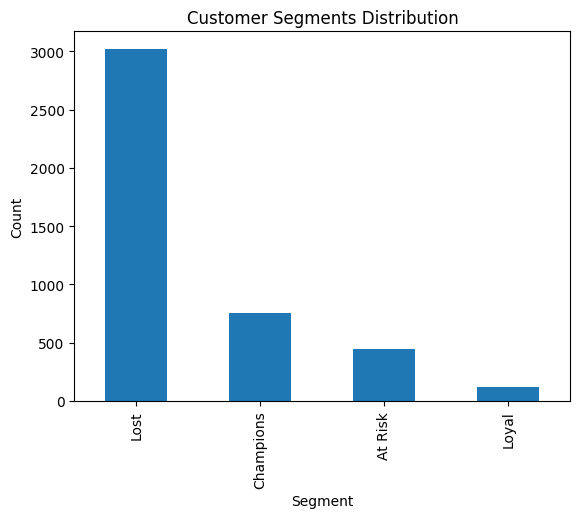

In [26]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

INsights:
- The majority of customers fall into the Lost segment, indicating a large portion of inactive or low-engagement users.
- A moderate number of customers are classified as Champions, suggesting a valuable but relatively smaller high-performing group.
- The At Risk segment represents customers who were previously active but are now less engaged.
- The Loyal segment is the smallest, indicating fewer consistently engaged customers over time.

# Campaign Strategies

*Champions (High R, F, M)*

Strategy: “Controlled Exclusivity + Spend Amplification”

Instead of just rewards:

Give early access to limited stock / drops
Offer tiered perks based on spend thresholds (e.g., spend ₹X more → unlock premium benefit)

Why:
They already buy - goal is increase basket size, not just retain
Scarcity + status drives higher spending

*Loyal (High F, moderate M)*

Strategy: “Upgrade Their Basket, Not Their Frequency”

Bundle products:
“Frequently bought together”
Offer:
Upsell nudges instead of discounts
e.g., “Add ₹200 more for premium variant”

Why:
They already purchase often
Problem = low ticket size, not engagement

*At Risk (Low R, decent F/M)*

Strategy: “Personalized Recall Trigger (Not Discount Blast)”

Use:
Last purchased category
Send:
“Back in stock” / “New arrivals in your category”

Why:
They didn’t stop liking you
They just lost relevance / timing

This is better than a generic 20% off spam

*Lost (Low R, low F)*

Strategy: “Selective Reactivation + Strategic Deprioritization”

Identify a subset of lost customers based on past value (e.g., higher monetary contribution).
For this group:
Run targeted win-back campaigns with strong, time-bound incentives.
For the remaining low-value customers:
Limit marketing spend and focus on higher-return segments.

Why:
The segment is large, but not all customers contribute equally.
Selective reactivation ensures efficient use of resources while avoiding unnecessary marketing costs.

While reactivation efforts can recover some customers, long-term growth is better achieved by focusing on retention strategies for active and high-value segments.

In [28]:
rfm_final = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']]

rfm_final.to_csv("rfm_customer_segments.csv", index=False)